# Step 4 — Public Council Resolutions and Reports

## Objective

This notebook extracts, cleans, and curates publicly available
council resolutions and reports associated with Kabwe Municipal Council.

The information will be obtained from official Kabwe Municipal Council
webpages and official council documents.

The dataset will focus on:

- public council resolutions;
- council reports;
- annual reports;
- financial reports;
- budget reports;
- council meeting documents or minutes where publicly available; and
- other official reports published by the Council.

For each record, relevant metadata such as the document title,
document type, publication date or year where available, description,
and official source URL will be retained.

Source URLs will be retained to provide data provenance.

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Official Kabwe Municipal Council website

council_base_url = "https://www.kabwecouncil.gov.zm"

print("Official council website:")
print(council_base_url)

Official council website:
https://www.kabwecouncil.gov.zm


In [3]:
# Test whether the official Council website is accessible.

response = requests.get(
    council_base_url,
    timeout=30,
    verify=False
)

print("Status code:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))
print("Page size:", len(response.text), "characters")

C:\Users\Pardo\AppData\Local\Programs\Python\Python314\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.kabwecouncil.gov.zm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Status code: 200
Content type: text/html; charset=UTF-8
Page size: 167369 characters


In [4]:
# Parse the Council homepage.

soup = BeautifulSoup(
    response.text,
    "html.parser"
)

# Extract all links from the homepage.

all_links = []

for link in soup.find_all("a", href=True):

    link_text = link.get_text(
        " ",
        strip=True
    )

    all_links.append(
        {
            "link_text": link_text,
            "url": link["href"]
        }
    )

links_df = pd.DataFrame(all_links)

print("Total links found:", len(links_df))

display(links_df.head(20))

Total links found: 122


,link_text,url
0,,#
1,Home,https://www.kabwecouncil.gov.zm/
2,About,#
3,About Us,https://www.kabwecouncil.gov.zm/?page_id=2601
4,Mandate,https://www.kabwecouncil.gov.zm/?page_id=169
5,Who we are,https://www.kabwecouncil.gov.zm/?page_id=118
6,Departments,https://www.kabwecouncil.gov.zm/?page_id=770
7,office of the the town clerk,https://www.kabwecouncil.gov.zm/?page_id=2634
8,Dept of Human Resource and Administration,https://www.kabwecouncil.gov.zm/?page_id=2637
9,Dept of Health,https://www.kabwecouncil.gov.zm/?page_id=2640


In [5]:
# Search the homepage links for terms related to
# council resolutions, reports, meetings and publications.

keywords = [
    "report",
    "resolution",
    "minutes",
    "meeting",
    "budget",
    "publication",
    "document",
    "financial",
    "annual",
    "plan",
    "statement"
]

potential_links = []

for _, row in links_df.iterrows():

    link_text = str(row["link_text"]).lower()
    url = str(row["url"]).lower()

    if any(
        keyword in link_text or keyword in url
        for keyword in keywords
    ):
        potential_links.append(
            {
                "link_text": row["link_text"],
                "url": row["url"]
            }
        )

potential_links_df = pd.DataFrame(
    potential_links
).drop_duplicates()

print(
    "Potential report/resolution-related links:",
    len(potential_links_df)
)

display(potential_links_df)

Potential report/resolution-related links: 5


,link_text,url
0,Dept Of Planning,https://www.kabwecouncil.gov.zm/?page_id=3897
1,Publications,https://www.kabwecouncil.gov.zm/?page_id=195
4,Download Latest Statement,https://www.katetecouncil.gov.zm/wp-content/up...
5,View Previous Statements,https://www.katetecouncil.gov.zm/wp-content/up...
6,Ministry of Finance and National Planning,https://www.mofnp.gov.zm/


In [6]:
# Official Kabwe Municipal Council Publications page

publications_url = (
    council_base_url + "/?page_id=195"
)

publications_response = requests.get(
    publications_url,
    timeout=30,
    verify=False
)

print("Publications page:")
print("URL:", publications_url)
print("Status code:", publications_response.status_code)
print(
    "Content type:",
    publications_response.headers.get("Content-Type")
)
print(
    "Page size:",
    len(publications_response.text),
    "characters"
)

C:\Users\Pardo\AppData\Local\Programs\Python\Python314\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.kabwecouncil.gov.zm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Publications page:
URL: https://www.kabwecouncil.gov.zm/?page_id=195
Status code: 200
Content type: text/html; charset=UTF-8
Page size: 111141 characters


In [7]:
# Extract readable text from the official Publications page.

publications_soup = BeautifulSoup(
    publications_response.text,
    "html.parser"
)

publications_text = publications_soup.get_text(
    separator="\n",
    strip=True
)

print("First 5000 characters of the Publications page:")
print("=" * 60)
print(publications_text[:5000])

First 5000 characters of the Publications page:
Publications – Kabwe Municipal Council
Home
About
Open menu
About Us
Mandate
Who we are
Departments
office of the the town clerk
Dept of Human Resource and Administration
Dept of Health
Dept of Finance
Dept of Engineering Services
Dept of Health Services
Dept Legal ( Services Unit)
Dept Of Planning
Dept Of Housing and Social Services
Dept of Fisheries, Livestock And Veterinary Services
Dept of Agriculture
Civic Leaders
The Mayor
Kabwe Central
Bwacha
Services
Open menu
Licenses and levies
Waste Management
E-GP
News Updates
CDF
Open menu
CDF GUIDLINES
CDF branding guidelines
ZDSP
Media
Open menu
Publications
Public Notices
Photo Gallery
video gallery
Forms
ADD A VIDEO
Contact Us
FAQS
Menu
Home
About
Open menu
About Us
Mandate
Who we are
Departments
office of the the town clerk
Dept of Human Resource and Administration
Dept of Health
Dept of Finance
Dept of Engineering Services
Dept of Health Services
Dept Legal ( Services Unit)
Dept Of Plan

In [8]:
# Extract all links from the official Publications page.

publication_links = []

for link in publications_soup.find_all("a", href=True):

    link_text = link.get_text(
        " ",
        strip=True
    )

    publication_links.append(
        {
            "title": link_text,
            "url": link["href"]
        }
    )

publication_links_df = pd.DataFrame(
    publication_links
)

# Remove empty link text and duplicate links.
publication_links_df = publication_links_df[
    publication_links_df["title"].notna()
]

publication_links_df = publication_links_df[
    publication_links_df["title"].str.strip() != ""
]

publication_links_df = (
    publication_links_df
    .drop_duplicates()
    .reset_index(drop=True)
)

print(
    "Total publication-page links:",
    len(publication_links_df)
)

display(publication_links_df)

Total publication-page links: 116


,title,url
0,Home,https://www.kabwecouncil.gov.zm/
1,About,#
2,About Us,https://www.kabwecouncil.gov.zm/?page_id=2601
3,Mandate,https://www.kabwecouncil.gov.zm/?page_id=169
4,Who we are,https://www.kabwecouncil.gov.zm/?page_id=118
...,...,...
111,Ministry of Finance and National Planning,https://www.mofnp.gov.zm/
112,Ministry of Agriculture,https://www.agriculture.gov.zm/
113,National Assembly of Zambia,https://www.parliament.gov.zm/
114,Local Government Training Institute,http://www.clgti.co.zm/


In [9]:
# Keywords that identify reports, statements, minutes,
# budgets and other relevant Council documents.

document_keywords = [
    "financial statement",
    "budget",
    "minutes",
    "report",
    "press statement",
    "stakeholder",
    "council meeting",
    "council minutes",
    "procurement plan",
    "citizen engagement",
    "service charter"
]

relevant_document_links = []

for _, row in publication_links_df.iterrows():

    title = str(row["title"]).strip()
    title_lower = title.lower()

    if any(
        keyword in title_lower
        for keyword in document_keywords
    ):
        relevant_document_links.append(
            {
                "title": title,
                "url": row["url"]
            }
        )

relevant_documents_df = pd.DataFrame(
    relevant_document_links
).drop_duplicates()

print(
    "Relevant document links found:",
    len(relevant_documents_df)
)

display(relevant_documents_df)

Relevant document links found: 36


,title,url
0,2018 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
1,2019 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
2,2020 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
3,2021 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
4,2022 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
5,2023 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
6,2024 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
7,2025 BI Annual Budget Performance Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
8,2025 BI Annual Budget Performance Report template,https://www.kabwecouncil.gov.zm/wp-content/upl...
9,2024 Budget Head Mandate Objective,https://www.kabwecouncil.gov.zm/wp-content/upl...


In [10]:
# Display all potentially relevant documents
# with their index numbers.

relevant_documents_display = (
    relevant_documents_df
    .reset_index(drop=True)
    .copy()
)

relevant_documents_display.index = (
    relevant_documents_display.index + 1
)

display(relevant_documents_display)

,title,url
1,2018 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
2,2019 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
3,2020 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
4,2021 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
5,2022 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
6,2023 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
7,2024 Financial Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
8,2025 BI Annual Budget Performance Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
9,2025 BI Annual Budget Performance Report template,https://www.kabwecouncil.gov.zm/wp-content/upl...
10,2024 Budget Head Mandate Objective,https://www.kabwecouncil.gov.zm/wp-content/upl...


In [11]:
# Classify the candidate publications according to the
# "Public Council Resolutions and Reports" assignment scope.

def classify_document(title):

    title_lower = title.lower()

    if "financial statement" in title_lower:
        return "Financial Report"

    if "annual budget performance report" in title_lower:
        return "Budget Performance Report"

    if "minutes" in title_lower:
        if "ordinary council" in title_lower:
            return "Council Meeting Minutes"
        return "Meeting Minutes"

    if "press statement" in title_lower:
        return "Press Statement"

    if "budget" in title_lower and "meeting" not in title_lower:
        return "Budget Document"

    return "Other Official Document"


relevant_documents_display["document_type"] = (
    relevant_documents_display["title"]
    .apply(classify_document)
)

display(
    relevant_documents_display[
        [
            "title",
            "document_type",
            "url"
        ]
    ]
)

,title,document_type,url
1,2018 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
2,2019 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
3,2020 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
4,2021 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
5,2022 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
6,2023 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
7,2024 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
8,2025 BI Annual Budget Performance Report,Budget Performance Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
9,2025 BI Annual Budget Performance Report template,Budget Performance Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
10,2024 Budget Head Mandate Objective,Budget Document,https://www.kabwecouncil.gov.zm/wp-content/upl...


In [12]:
# Identify documents that directly fit the assigned
# "Public Council Resolutions and Reports" component.

included_types = [
    "Financial Report",
    "Budget Performance Report",
    "Council Meeting Minutes",
    "Meeting Minutes",
    "Press Statement",
    "Budget Document"
]

public_reports_df = relevant_documents_display[
    relevant_documents_display["document_type"].isin(
        included_types
    )
].copy()

public_reports_df = (
    public_reports_df
    .reset_index(drop=True)
)

print(
    "Documents included in the public reports/resolutions dataset:",
    len(public_reports_df)
)

display(
    public_reports_df[
        [
            "title",
            "document_type",
            "url"
        ]
    ]
)

Documents included in the public reports/resolutions dataset: 26


,title,document_type,url
0,2018 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
1,2019 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
2,2020 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
3,2021 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
4,2022 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
5,2023 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
6,2024 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
7,2025 BI Annual Budget Performance Report,Budget Performance Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
8,2025 BI Annual Budget Performance Report template,Budget Performance Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
9,2024 Budget Head Mandate Objective,Budget Document,https://www.kabwecouncil.gov.zm/wp-content/upl...


In [13]:
# Check the accessibility and file type of each selected document.

document_checks = []

for _, row in public_reports_df.iterrows():

    url = row["url"]

    try:
        response = requests.get(
            url,
            timeout=30,
            verify=False,
            allow_redirects=True
        )

        content_type = response.headers.get(
            "Content-Type",
            ""
        )

        document_checks.append(
            {
                "title": row["title"],
                "document_type": row["document_type"],
                "status_code": response.status_code,
                "content_type": content_type,
                "final_url": response.url,
                "url": url
            }
        )

    except Exception as error:

        document_checks.append(
            {
                "title": row["title"],
                "document_type": row["document_type"],
                "status_code": "ERROR",
                "content_type": "",
                "final_url": "",
                "url": url
            }
        )

document_checks_df = pd.DataFrame(
    document_checks
)

print(
    "Documents checked:",
    len(document_checks_df)
)

display(document_checks_df)

C:\Users\Pardo\AppData\Local\Programs\Python\Python314\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.kabwecouncil.gov.zm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Pardo\AppData\Local\Programs\Python\Python314\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.kabwecouncil.gov.zm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
C:\Users\Pardo\AppData\Local\Programs\Python\Python314\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.kabwecouncil.gov.zm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/l

Documents checked: 26


,title,document_type,status_code,content_type,final_url,url
0,2018 Financial Statement,Financial Report,200,application/pdf,https://www.kabwecouncil.gov.zm/wp-content/upl...,https://www.kabwecouncil.gov.zm/wp-content/upl...
1,2019 Financial Statement,Financial Report,200,application/pdf,https://www.kabwecouncil.gov.zm/wp-content/upl...,https://www.kabwecouncil.gov.zm/wp-content/upl...
2,2020 Financial Statement,Financial Report,200,application/pdf,https://www.kabwecouncil.gov.zm/wp-content/upl...,https://www.kabwecouncil.gov.zm/wp-content/upl...
3,2021 Financial Statement,Financial Report,200,application/pdf,https://www.kabwecouncil.gov.zm/wp-content/upl...,https://www.kabwecouncil.gov.zm/wp-content/upl...
4,2022 Financial Statement,Financial Report,200,application/pdf,https://www.kabwecouncil.gov.zm/wp-content/upl...,https://www.kabwecouncil.gov.zm/wp-content/upl...
5,2023 Financial Statement,Financial Report,200,application/pdf,https://www.kabwecouncil.gov.zm/wp-content/upl...,https://www.kabwecouncil.gov.zm/wp-content/upl...
6,2024 Financial Statement,Financial Report,200,application/pdf,https://www.kabwecouncil.gov.zm/wp-content/upl...,https://www.kabwecouncil.gov.zm/wp-content/upl...
7,2025 BI Annual Budget Performance Report,Budget Performance Report,200,application/pdf,https://www.kabwecouncil.gov.zm/wp-content/upl...,https://www.kabwecouncil.gov.zm/wp-content/upl...
8,2025 BI Annual Budget Performance Report template,Budget Performance Report,200,application/pdf,https://www.kabwecouncil.gov.zm/wp-content/upl...,https://www.kabwecouncil.gov.zm/wp-content/upl...
9,2024 Budget Head Mandate Objective,Budget Document,200,application/pdf,https://www.kabwecouncil.gov.zm/wp-content/upl...,https://www.kabwecouncil.gov.zm/wp-content/upl...


In [14]:
# Remove documents that should not be included in the
# final public council resolutions/reports dataset.

excluded_titles = [
    "2025 BI Annual Budget Performance Report template",
    "5 . Minutes of the Budget meeting"
]

public_reports_clean_df = public_reports_df[
    ~public_reports_df["title"].isin(excluded_titles)
].copy()

public_reports_clean_df = (
    public_reports_clean_df
    .reset_index(drop=True)
)

print(
    "Documents remaining after quality filtering:",
    len(public_reports_clean_df)
)

display(
    public_reports_clean_df[
        [
            "title",
            "document_type",
            "url"
        ]
    ]
)

Documents remaining after quality filtering: 24


,title,document_type,url
0,2018 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
1,2019 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
2,2020 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
3,2021 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
4,2022 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
5,2023 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
6,2024 Financial Statement,Financial Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
7,2025 BI Annual Budget Performance Report,Budget Performance Report,https://www.kabwecouncil.gov.zm/wp-content/upl...
8,2024 Budget Head Mandate Objective,Budget Document,https://www.kabwecouncil.gov.zm/wp-content/upl...
9,2025 Kabwe Municipal Council OBB Approved Budget,Budget Document,https://www.kabwecouncil.gov.zm/wp-content/upl...


In [15]:
# Extract the year from each document title where a year is stated.

import re

def extract_year(title):

    match = re.search(
        r"\b(20\d{2})\b",
        str(title)
    )

    if match:
        return int(match.group(1))

    return None


public_reports_clean_df["publication_year"] = (
    public_reports_clean_df["title"]
    .apply(extract_year)
)

display(
    public_reports_clean_df[
        [
            "title",
            "document_type",
            "publication_year"
        ]
    ]
)

,title,document_type,publication_year
0,2018 Financial Statement,Financial Report,2018.0
1,2019 Financial Statement,Financial Report,2019.0
2,2020 Financial Statement,Financial Report,2020.0
3,2021 Financial Statement,Financial Report,2021.0
4,2022 Financial Statement,Financial Report,2022.0
5,2023 Financial Statement,Financial Report,2023.0
6,2024 Financial Statement,Financial Report,2024.0
7,2025 BI Annual Budget Performance Report,Budget Performance Report,2025.0
8,2024 Budget Head Mandate Objective,Budget Document,2024.0
9,2025 Kabwe Municipal Council OBB Approved Budget,Budget Document,2025.0


In [16]:
# Identify documents whose publication year could not be
# determined from the title.

missing_year_df = public_reports_clean_df[
    public_reports_clean_df["publication_year"].isna()
].copy()

missing_year_df = (
    missing_year_df
    .reset_index(drop=True)
)

print(
    "Documents with missing publication year:",
    len(missing_year_df)
)

display(
    missing_year_df[
        [
            "title",
            "document_type",
            "url"
        ]
    ]
)

Documents with missing publication year: 6


,title,document_type,url
0,Budget Performance Minutes of the budget Meeting,Meeting Minutes,https://www.kabwecouncil.gov.zm/wp-content/upl...
1,CDF PRESS STATEMENT,Press Statement,https://www.kabwecouncil.gov.zm/wp-content/upl...
2,Minutes of Stakeholders Meeting,Meeting Minutes,https://www.kabwecouncil.gov.zm/wp-content/upl...
3,4 . Stakeholder engagement minutes of the Budg...,Meeting Minutes,https://www.kabwecouncil.gov.zm/wp-content/upl...
4,6 . Minutes of the consultative budget meeting,Meeting Minutes,https://www.kabwecouncil.gov.zm/wp-content/upl...
5,7 . Minutes of the meeting of the budget fee,Meeting Minutes,https://www.kabwecouncil.gov.zm/wp-content/upl...


In [17]:
# Download the documents with missing publication years
# so that their contents can be inspected.

from pathlib import Path

documents_folder = Path("council_documents")

documents_folder.mkdir(
    exist_ok=True
)

downloaded_documents = []

for index, row in missing_year_df.iterrows():

    url = row["url"]

    try:
        response = requests.get(
            url,
            timeout=30,
            verify=False
        )

        response.raise_for_status()

        content_type = response.headers.get(
            "Content-Type",
            ""
        ).lower()

        if "pdf" in content_type:
            extension = ".pdf"

        elif "word" in content_type or "officedocument" in content_type:
            extension = ".docx"

        else:
            extension = ".bin"

        file_path = (
            documents_folder /
            f"document_{index + 1}{extension}"
        )

        with open(
            file_path,
            "wb"
        ) as file:

            file.write(response.content)

        downloaded_documents.append(
            {
                "title": row["title"],
                "file_path": str(file_path),
                "content_type": content_type
            }
        )

        print(
            "Downloaded:",
            row["title"]
        )

    except Exception as error:

        print(
            "Failed:",
            row["title"]
        )

        print(
            "Error:",
            error
        )

downloaded_documents_df = pd.DataFrame(
    downloaded_documents
)

print()
print(
    "Documents downloaded:",
    len(downloaded_documents_df)
)

display(downloaded_documents_df)

C:\Users\Pardo\AppData\Local\Programs\Python\Python314\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.kabwecouncil.gov.zm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Downloaded: Budget Performance Minutes of the budget Meeting


C:\Users\Pardo\AppData\Local\Programs\Python\Python314\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.kabwecouncil.gov.zm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Downloaded: CDF PRESS STATEMENT


C:\Users\Pardo\AppData\Local\Programs\Python\Python314\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.kabwecouncil.gov.zm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


...

C:\Users\Pardo\AppData\Local\Programs\Python\Python314\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.kabwecouncil.gov.zm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Downloaded: 6 . Minutes of the consultative budget meeting


C:\Users\Pardo\AppData\Local\Programs\Python\Python314\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.kabwecouncil.gov.zm'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Downloaded: 7 . Minutes of the meeting of the budget fee

Documents downloaded: 6


,title,file_path,content_type
0,Budget Performance Minutes of the budget Meeting,council_documents\document_1.pdf,application/pdf
1,CDF PRESS STATEMENT,council_documents\document_2.docx,application/vnd.openxmlformats-officedocument....
2,Minutes of Stakeholders Meeting,council_documents\document_3.pdf,application/pdf
3,4 . Stakeholder engagement minutes of the Budg...,council_documents\document_4.pdf,application/pdf
4,6 . Minutes of the consultative budget meeting,council_documents\document_5.pdf,application/pdf
5,7 . Minutes of the meeting of the budget fee,council_documents\document_6.pdf,application/pdf


In [18]:
# Extract text from the downloaded PDF and DOCX documents.

import fitz
from docx import Document

document_texts = []

for _, row in downloaded_documents_df.iterrows():

    file_path = row["file_path"]
    content_type = row["content_type"]

    text = ""

    try:

        if file_path.endswith(".pdf"):

            pdf = fitz.open(file_path)

            for page in pdf:
                text += page.get_text()

            pdf.close()

        elif file_path.endswith(".docx"):

            doc = Document(file_path)

            for paragraph in doc.paragraphs:
                text += paragraph.text + "\n"

        document_texts.append(
            {
                "title": row["title"],
                "file_path": file_path,
                "text": text
            }
        )

        print(
            "Extracted:",
            row["title"]
        )

    except Exception as error:

        print(
            "Failed:",
            row["title"]
        )

        print(
            "Error:",
            error
        )

document_texts_df = pd.DataFrame(
    document_texts
)

print()
print(
    "Documents with extracted text:",
    len(document_texts_df)
)

ModuleNotFoundError: No module named 'fitz'

In [19]:
# Install PyMuPDF for extracting text from PDF files.

%pip install PyMuPDF

   ---------------------------------------- 0.0/19.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/19.8 MB ? eta -:--:--
    --------------------------------------- 0.3/19.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/19.8 MB 1.3 MB/s eta 0:00:16
   - -------------------------------------- 0.5/19.8 MB 1.3 MB/s eta 0:00:16
   -- ------------------------------------- 1.0/19.8 MB 1.4 MB/s eta 0:00:14
   --- ------------------------------------ 1.6/19.8 MB 1.5 MB/s eta 0:00:12
   --- ------------------------------------ 1.8/19.8 MB 1.6 MB/s eta 0:00:12
   ---- ----------------------------------- 2.4/19.8 MB 1.7 MB/s eta 0:00:11
   ----- ---------------------------------- 2.9/19.8 MB 1.7 MB/s eta 0:00:10
   ------ --------------------------------- 3.4/19.8 MB 1.8 MB/s eta 0:00:09
   ------ --------------------------------- 3.4/19.8 MB 1.8 MB/s eta 0:00:09
   ------- ----------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# Extract text from the downloaded PDF and DOCX documents.

import fitz
from docx import Document

document_texts = []

for _, row in downloaded_documents_df.iterrows():

    file_path = row["file_path"]
    content_type = row["content_type"]

    text = ""

    try:

        if file_path.endswith(".pdf"):

            pdf = fitz.open(file_path)

            for page in pdf:
                text += page.get_text()

            pdf.close()

        elif file_path.endswith(".docx"):

            doc = Document(file_path)

            for paragraph in doc.paragraphs:
                text += paragraph.text + "\n"

        document_texts.append(
            {
                "title": row["title"],
                "file_path": file_path,
                "text": text
            }
        )

        print(
            "Extracted:",
            row["title"]
        )

    except Exception as error:

        print(
            "Failed:",
            row["title"]
        )

        print(
            "Error:",
            error
        )

document_texts_df = pd.DataFrame(
    document_texts
)

print()
print(
    "Documents with extracted text:",
    len(document_texts_df)
)

ModuleNotFoundError: No module named 'docx'

In [21]:
# Install python-docx for reading Word documents.

%pip install python-docx

   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   -- ----------------------------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
# Extract text from the downloaded PDF and DOCX documents.

import pymupdf
from docx import Document

document_texts = []

for _, row in downloaded_documents_df.iterrows():

    file_path = row["file_path"]

    text = ""

    try:

        if file_path.endswith(".pdf"):

            pdf = pymupdf.open(file_path)

            for page in pdf:
                text += page.get_text()

            pdf.close()

        elif file_path.endswith(".docx"):

            doc = Document(file_path)

            for paragraph in doc.paragraphs:
                text += paragraph.text + "\n"

        document_texts.append(
            {
                "title": row["title"],
                "file_path": file_path,
                "text": text
            }
        )

        print(
            "Extracted:",
            row["title"]
        )

    except Exception as error:

        print(
            "Failed:",
            row["title"]
        )

        print(
            "Error:",
            error
        )

document_texts_df = pd.DataFrame(
    document_texts
)

print()
print(
    "Documents with extracted text:",
    len(document_texts_df)
)

Extracted: Budget Performance Minutes of the budget Meeting
Extracted: CDF PRESS STATEMENT
Extracted: Minutes of Stakeholders Meeting
Extracted: 4 . Stakeholder engagement minutes of the Budget meeting
Extracted: 6 . Minutes of the consultative budget meeting
Extracted: 7 . Minutes of the meeting of the budget fee

Documents with extracted text: 6


In [23]:
# Search the extracted document text for years.

year_pattern = r"\b20\d{2}\b"

for _, row in document_texts_df.iterrows():

    years_found = sorted(
        set(
            re.findall(
                year_pattern,
                row["text"]
            )
        )
    )

    print("=" * 80)
    print("DOCUMENT:", row["title"])
    print("YEARS FOUND:", years_found)

DOCUMENT: Budget Performance Minutes of the budget Meeting
YEARS FOUND: []
DOCUMENT: CDF PRESS STATEMENT
YEARS FOUND: ['2023']
DOCUMENT: Minutes of Stakeholders Meeting
YEARS FOUND: ['2014', '2023', '2024']
DOCUMENT: 4 . Stakeholder engagement minutes of the Budget meeting
YEARS FOUND: []
DOCUMENT: 6 . Minutes of the consultative budget meeting
YEARS FOUND: []
DOCUMENT: 7 . Minutes of the meeting of the budget fee
YEARS FOUND: []


In [24]:
# Display the beginning of each document to inspect
# titles, dates, meeting information and other metadata.

for _, row in document_texts_df.iterrows():

    print("=" * 100)
    print("DOCUMENT:", row["title"])
    print("=" * 100)

    text = row["text"].strip()

    print(
        text[:3000]
    )

    print("\n")

DOCUMENT: Budget Performance Minutes of the budget Meeting



DOCUMENT: CDF PRESS STATEMENT
PRESS STATEMENT

FOR IMMEDIATE RELEASE.
            
2023 CDF GRANTS          AND LOANS DISBURSED IN BWACHA CONSTITUENCY.

Kabwe, 16 October, 2023

Bwacha Constituency has today disbursed the 2023 Constituency Development Fund (CDF) empowerment Grants and Loans with a total amount of Three point Six Million Twenty-Nine Thousand Four Hundred Eighty-Five Kwacha (K3, 629, 485).

Speaking during the handover ceremony today, Central Province Permanent Secretary Mr Milner Mwanakampwe said that One point Four Million Seventy-Seven Thousand Five Hundred Seventy- Five Kwacha (1, 477, 575) has been disbursed to Fifteen (15) CDF Loan beneficiaries and Two point One Million Fifty- One Thousand Nine Hundred Ten Kwacha (2,151,910) has been disbursed to Seventy -One (71) CDF Grants beneficiaries respectively.

Mr Mwanakampwe pointed out that the Government under the leadership of His excellence the President M

In [25]:
# Inspect PDF metadata and page counts for documents
# whose text could not be extracted.

for _, row in document_texts_df.iterrows():

    file_path = row["file_path"]

    if file_path.endswith(".pdf"):

        pdf = pymupdf.open(file_path)

        print("=" * 100)
        print("DOCUMENT:", row["title"])
        print("NUMBER OF PAGES:", len(pdf))
        print("PDF METADATA:")
        print(pdf.metadata)

        pdf.close()

DOCUMENT: Budget Performance Minutes of the budget Meeting
NUMBER OF PAGES: 11
PDF METADATA:
{'format': 'PDF 1.4', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'creator': '', 'producer': '', 'creationDate': '', 'modDate': '', 'trapped': '', 'encryption': None}
DOCUMENT: Minutes of Stakeholders Meeting
NUMBER OF PAGES: 8
PDF METADATA:
{'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'creator': 'Adobe Scan for Android 24.07.10-google-dynamic', 'producer': 'Adobe Acrobat DC Paper Capture Plug-in', 'creationDate': 'D:20240913125759Z', 'modDate': 'D:20240913125759Z', 'trapped': '', 'encryption': None}
DOCUMENT: 4 . Stakeholder engagement minutes of the Budget meeting
NUMBER OF PAGES: 8
PDF METADATA:
{'format': 'PDF 1.4', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'creator': '', 'producer': 'iLovePDF', 'creationDate': '', 'modDate': 'D:20250821090214Z', 'trapped': '', 'encryption': None}
DOCUMENT: 6 . Minutes of the consultative budg

In [26]:
# Render the first page of scanned PDFs as images
# so that dates and headings can be inspected.

from pathlib import Path

preview_folder = Path("council_documents/previews")

preview_folder.mkdir(
    exist_ok=True
)

for _, row in document_texts_df.iterrows():

    file_path = row["file_path"]

    if file_path.endswith(".pdf"):

        pdf = pymupdf.open(file_path)

        page = pdf[0]

        pixmap = page.get_pixmap(
            matrix=pymupdf.Matrix(2, 2)
        )

        safe_name = (
            row["title"]
            .replace("/", "_")
            .replace("\\", "_")
            .replace(" ", "_")
        )

        image_path = (
            preview_folder /
            f"{safe_name}.png"
        )

        pixmap.save(
            str(image_path)
        )

        print(
            "Created preview:",
            image_path
        )

        pdf.close()

Created preview: council_documents\previews\Budget_Performance_Minutes_of_the_budget_Meeting.png
Created preview: council_documents\previews\Minutes_of_Stakeholders_Meeting.png
Created preview: council_documents\previews\4_._Stakeholder_engagement_minutes_of_the_Budget_meeting.png
Created preview: council_documents\previews\6_._Minutes_of_the_consultative_budget_meeting.png
Created preview: council_documents\previews\7_._Minutes_of_the_meeting_of_the_budget_fee.png


DOCUMENT: Budget Performance Minutes of the budget Meeting


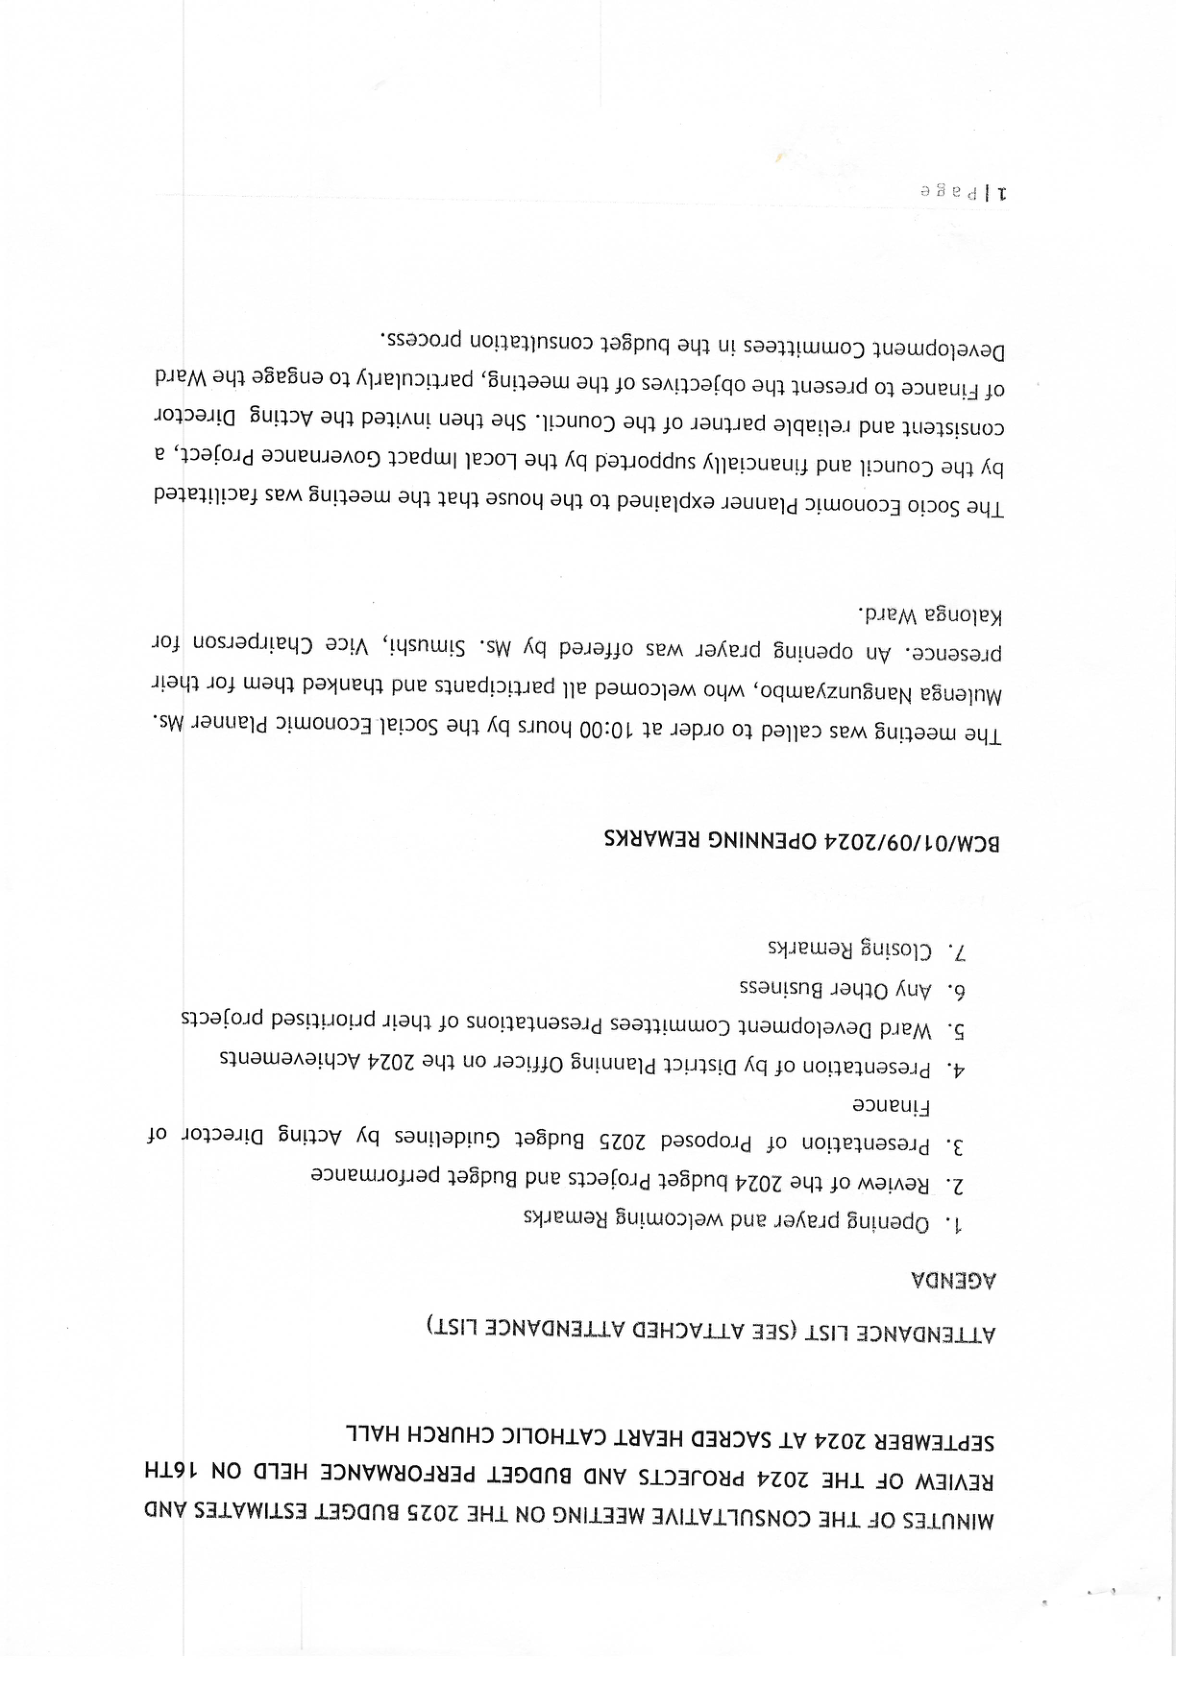

DOCUMENT: 4 . Stakeholder engagement minutes of the Budget meeting


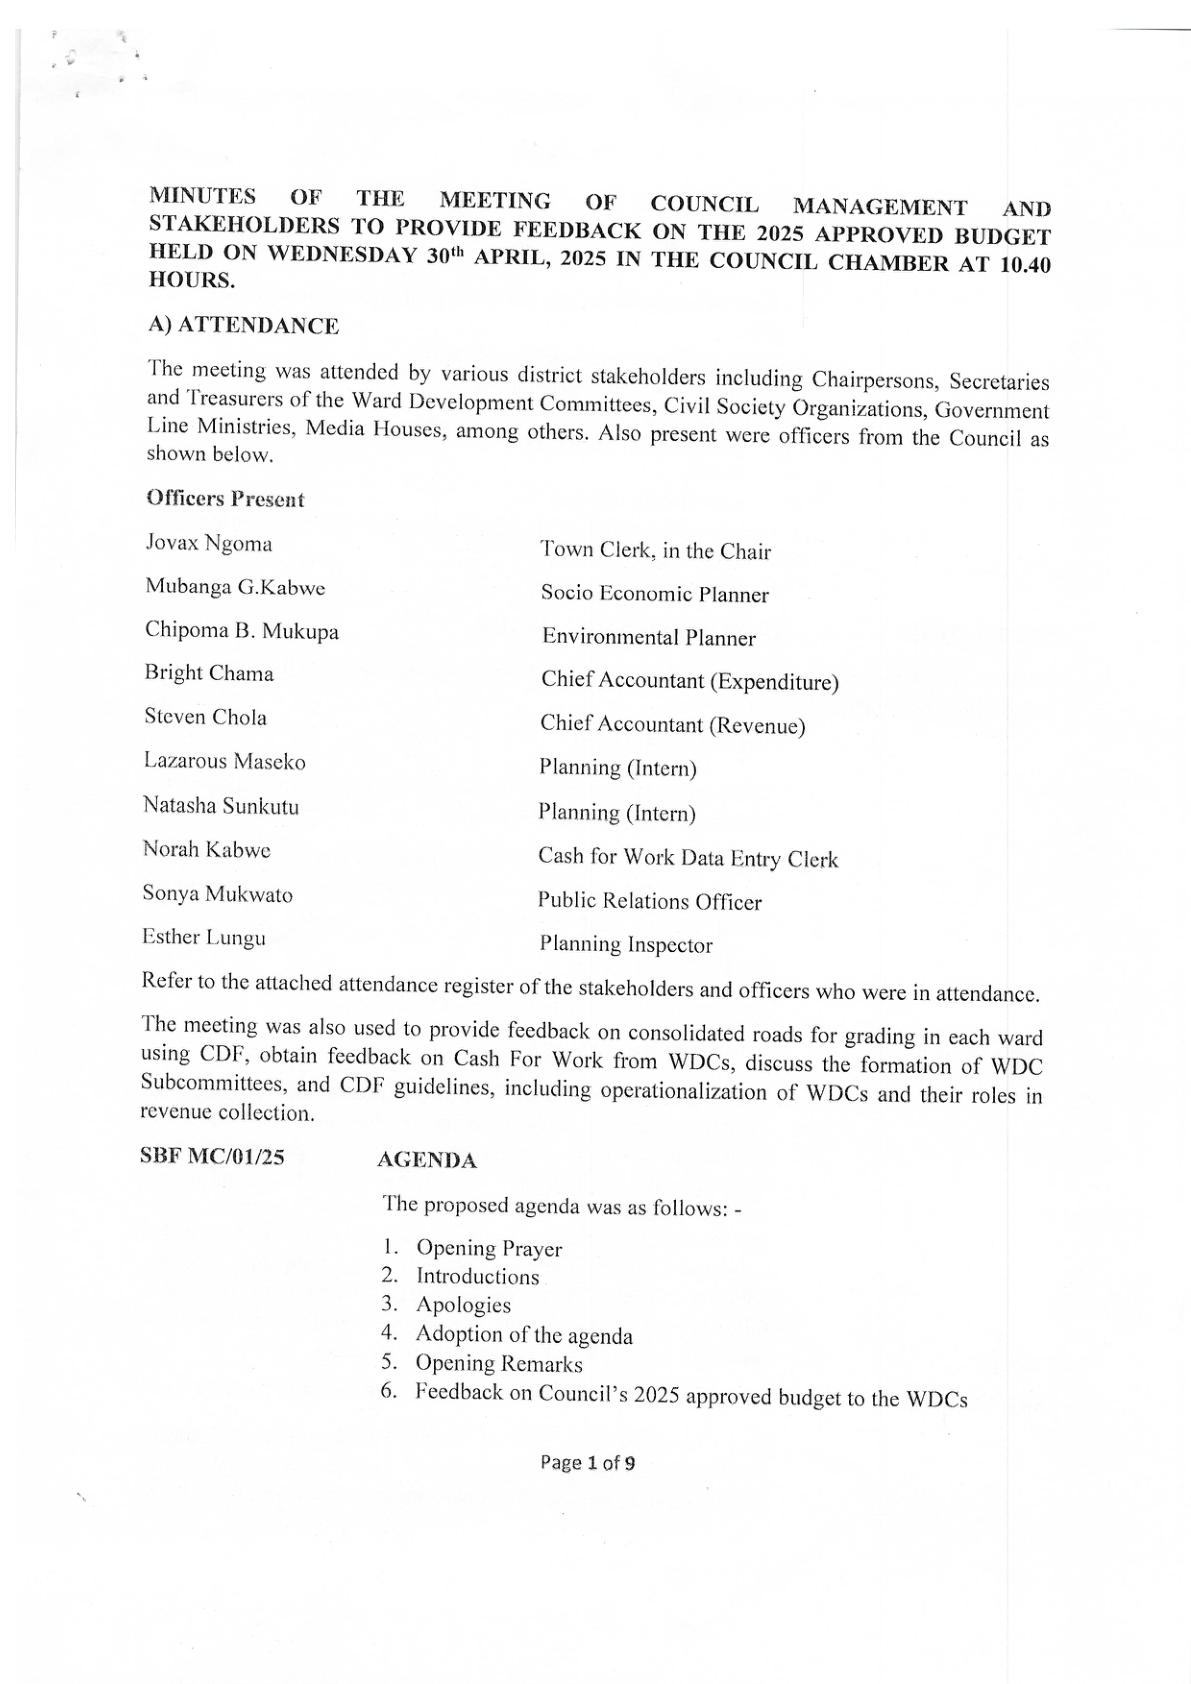

DOCUMENT: 6 . Minutes of the consultative budget meeting


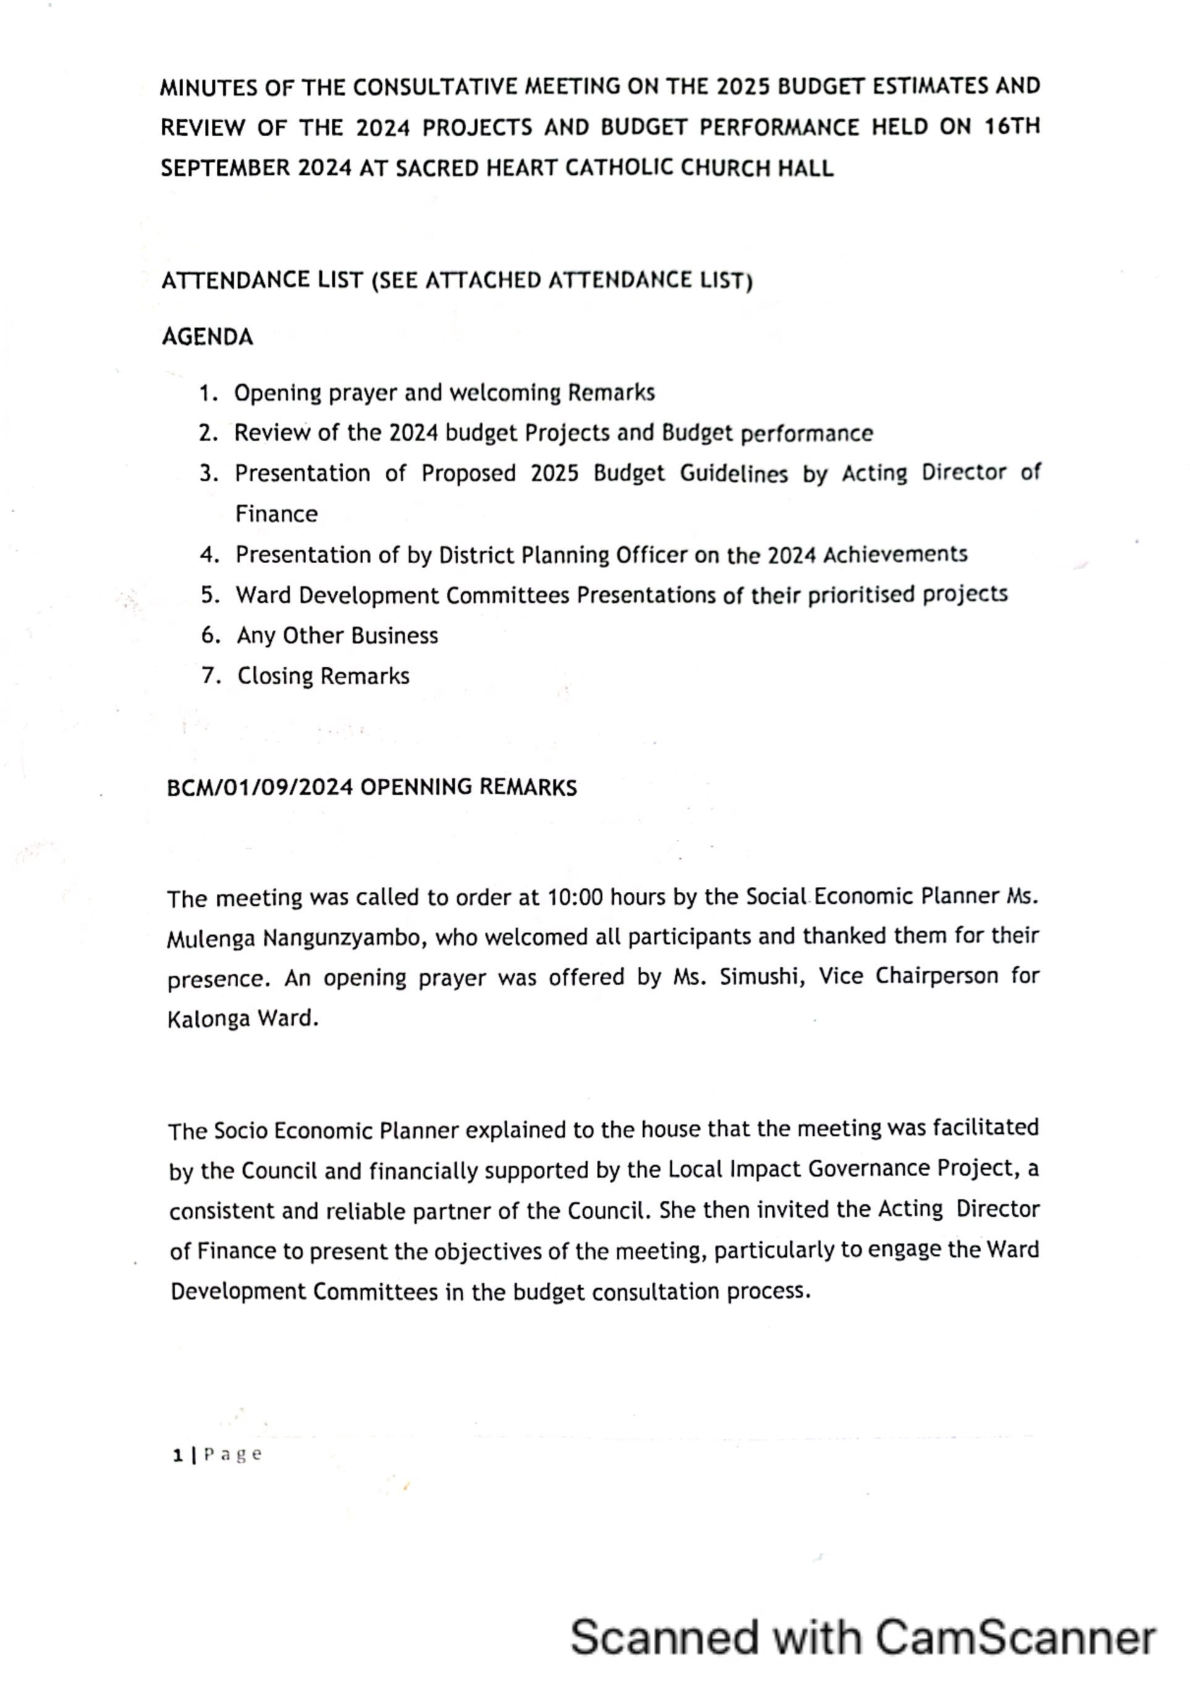

DOCUMENT: 7 . Minutes of the meeting of the budget fee


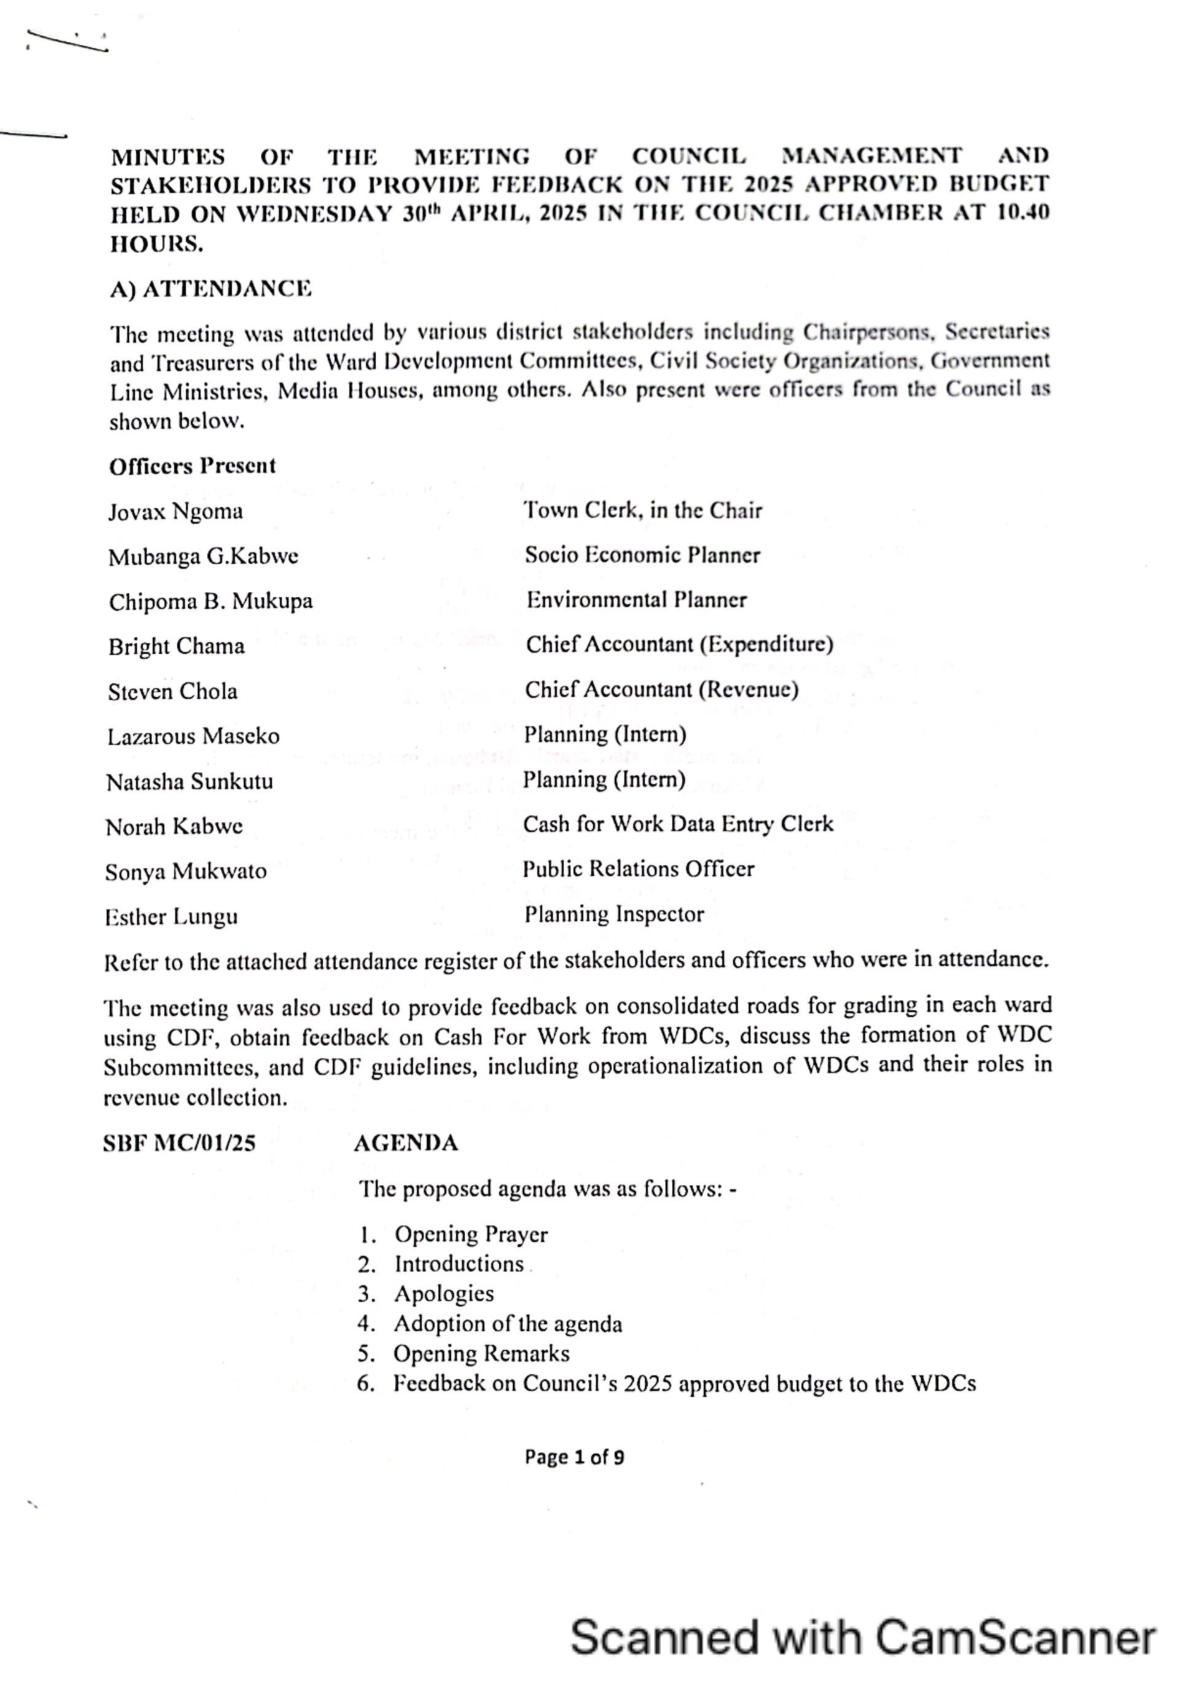

In [27]:
# Display the first page of each document whose year is still unknown.

from IPython.display import Image, display

unknown_document_titles = [
    "Budget Performance Minutes of the budget Meeting",
    "4 . Stakeholder engagement minutes of the Budget meeting",
    "6 . Minutes of the consultative budget meeting",
    "7 . Minutes of the meeting of the budget fee"
]

for title in unknown_document_titles:

    matching_file = None

    for _, row in document_texts_df.iterrows():

        if row["title"] == title:
            matching_file = row["file_path"]
            break

    if matching_file:

        safe_name = (
            title
            .replace("/", "_")
            .replace("\\", "_")
            .replace(" ", "_")
        )

        image_path = (
            Path("council_documents")
            / "previews"
            / f"{safe_name}.png"
        )

        print("=" * 80)
        print("DOCUMENT:", title)

        display(
            Image(
                filename=str(image_path)
            )
        )

In [28]:
# Fill the publication years that were verified
# by inspecting the actual document contents.

verified_years = {
    "Budget Performance Minutes of the budget Meeting": 2024,
    "CDF PRESS STATEMENT": 2023,
    "Minutes of Stakeholders Meeting": 2023,
    "4 . Stakeholder engagement minutes of the Budget meeting": 2025,
    "6 . Minutes of the consultative budget meeting": 2024,
    "7 . Minutes of the meeting of the budget fee": 2025
}

for title, year in verified_years.items():

    public_reports_clean_df.loc[
        public_reports_clean_df["title"] == title,
        "publication_year"
    ] = year


display(
    public_reports_clean_df[
        [
            "title",
            "document_type",
            "publication_year"
        ]
    ]
)

,title,document_type,publication_year
0,2018 Financial Statement,Financial Report,2018.0
1,2019 Financial Statement,Financial Report,2019.0
2,2020 Financial Statement,Financial Report,2020.0
3,2021 Financial Statement,Financial Report,2021.0
4,2022 Financial Statement,Financial Report,2022.0
5,2023 Financial Statement,Financial Report,2023.0
6,2024 Financial Statement,Financial Report,2024.0
7,2025 BI Annual Budget Performance Report,Budget Performance Report,2025.0
8,2024 Budget Head Mandate Objective,Budget Document,2024.0
9,2025 Kabwe Municipal Council OBB Approved Budget,Budget Document,2025.0


In [29]:
# Create a standardized description for each public
# council report/document.

def create_description(row):

    title = row["title"]
    document_type = row["document_type"]
    year = int(row["publication_year"])

    if document_type == "Financial Report":
        return (
            f"Kabwe Municipal Council financial statement "
            f"for the {year} financial year."
        )

    if document_type == "Budget Performance Report":
        return (
            f"Annual budget performance report for "
            f"Kabwe Municipal Council for {year}."
        )

    if document_type == "Council Meeting Minutes":
        return (
            f"Minutes of an ordinary Kabwe Municipal Council "
            f"meeting held in {year}."
        )

    if document_type == "Meeting Minutes":
        return (
            f"Minutes of a Kabwe Municipal Council meeting "
            f"or stakeholder consultation related to council "
            f"budget and planning activities in {year}."
        )

    if document_type == "Press Statement":
        return (
            f"Official Kabwe Municipal Council press statement "
            f"published in {year}."
        )

    if document_type == "Budget Document":
        return (
            f"Official Kabwe Municipal Council budget-related "
            f"document for {year}."
        )

    return (
        f"Official Kabwe Municipal Council document "
        f"published in {year}."
    )


public_reports_clean_df["description"] = (
    public_reports_clean_df
    .apply(create_description, axis=1)
)

display(
    public_reports_clean_df[
        [
            "title",
            "document_type",
            "publication_year",
            "description"
        ]
    ]
)

,title,document_type,publication_year,description
0,2018 Financial Statement,Financial Report,2018.0,Kabwe Municipal Council financial statement fo...
1,2019 Financial Statement,Financial Report,2019.0,Kabwe Municipal Council financial statement fo...
2,2020 Financial Statement,Financial Report,2020.0,Kabwe Municipal Council financial statement fo...
3,2021 Financial Statement,Financial Report,2021.0,Kabwe Municipal Council financial statement fo...
4,2022 Financial Statement,Financial Report,2022.0,Kabwe Municipal Council financial statement fo...
5,2023 Financial Statement,Financial Report,2023.0,Kabwe Municipal Council financial statement fo...
6,2024 Financial Statement,Financial Report,2024.0,Kabwe Municipal Council financial statement fo...
7,2025 BI Annual Budget Performance Report,Budget Performance Report,2025.0,Annual budget performance report for Kabwe Mun...
8,2024 Budget Head Mandate Objective,Budget Document,2024.0,Official Kabwe Municipal Council budget-relate...
9,2025 Kabwe Municipal Council OBB Approved Budget,Budget Document,2025.0,Official Kabwe Municipal Council budget-relate...


In [30]:
# Add source and provenance information to the dataset.

public_reports_clean_df["council"] = (
    "Kabwe Municipal Council"
)

public_reports_clean_df["source_type"] = (
    "Official Council Publication"
)

public_reports_clean_df["source_page"] = (
    publications_url
)

display(
    public_reports_clean_df[
        [
            "title",
            "document_type",
            "publication_year",
            "description",
            "council",
            "source_type",
            "source_page",
            "url"
        ]
    ]
)

,title,document_type,publication_year,description,council,source_type,source_page,url
0,2018 Financial Statement,Financial Report,2018.0,Kabwe Municipal Council financial statement fo...,Kabwe Municipal Council,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
1,2019 Financial Statement,Financial Report,2019.0,Kabwe Municipal Council financial statement fo...,Kabwe Municipal Council,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
2,2020 Financial Statement,Financial Report,2020.0,Kabwe Municipal Council financial statement fo...,Kabwe Municipal Council,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
3,2021 Financial Statement,Financial Report,2021.0,Kabwe Municipal Council financial statement fo...,Kabwe Municipal Council,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
4,2022 Financial Statement,Financial Report,2022.0,Kabwe Municipal Council financial statement fo...,Kabwe Municipal Council,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
5,2023 Financial Statement,Financial Report,2023.0,Kabwe Municipal Council financial statement fo...,Kabwe Municipal Council,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
6,2024 Financial Statement,Financial Report,2024.0,Kabwe Municipal Council financial statement fo...,Kabwe Municipal Council,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
7,2025 BI Annual Budget Performance Report,Budget Performance Report,2025.0,Annual budget performance report for Kabwe Mun...,Kabwe Municipal Council,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
8,2024 Budget Head Mandate Objective,Budget Document,2024.0,Official Kabwe Municipal Council budget-relate...,Kabwe Municipal Council,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
9,2025 Kabwe Municipal Council OBB Approved Budget,Budget Document,2025.0,Official Kabwe Municipal Council budget-relate...,Kabwe Municipal Council,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...


In [31]:
# Add the document file format to the dataset.

format_lookup = (
    document_checks_df[
        [
            "title",
            "content_type"
        ]
    ]
    .drop_duplicates("title")
)

public_reports_clean_df = public_reports_clean_df.merge(
    format_lookup,
    on="title",
    how="left"
)

def determine_file_format(content_type):

    content_type = str(content_type).lower()

    if "pdf" in content_type:
        return "PDF"

    if (
        "word" in content_type
        or "officedocument" in content_type
    ):
        return "DOCX"

    return "Other"


public_reports_clean_df["file_format"] = (
    public_reports_clean_df["content_type"]
    .apply(determine_file_format)
)

display(
    public_reports_clean_df[
        [
            "title",
            "document_type",
            "publication_year",
            "file_format"
        ]
    ]
)

,title,document_type,publication_year,file_format
0,2018 Financial Statement,Financial Report,2018.0,PDF
1,2019 Financial Statement,Financial Report,2019.0,PDF
2,2020 Financial Statement,Financial Report,2020.0,PDF
3,2021 Financial Statement,Financial Report,2021.0,PDF
4,2022 Financial Statement,Financial Report,2022.0,PDF
5,2023 Financial Statement,Financial Report,2023.0,PDF
6,2024 Financial Statement,Financial Report,2024.0,PDF
7,2025 BI Annual Budget Performance Report,Budget Performance Report,2025.0,PDF
8,2024 Budget Head Mandate Objective,Budget Document,2024.0,PDF
9,2025 Kabwe Municipal Council OBB Approved Budget,Budget Document,2025.0,PDF


In [32]:
# Remove the temporary content-type column
# and arrange the final dataset columns.

public_reports_clean_df = public_reports_clean_df.drop(
    columns=["content_type"]
)

public_reports_clean_df = public_reports_clean_df.rename(
    columns={
        "url": "source_url"
    }
)

final_columns = [
    "council",
    "title",
    "document_type",
    "publication_year",
    "description",
    "file_format",
    "source_type",
    "source_page",
    "source_url"
]

public_reports_clean_df = (
    public_reports_clean_df[
        final_columns
    ]
    .copy()
)

print(
    "Final dataset columns:",
    len(public_reports_clean_df.columns)
)

print(
    "Final dataset rows:",
    len(public_reports_clean_df)
)

display(public_reports_clean_df)

Final dataset columns: 9
Final dataset rows: 24


,council,title,document_type,publication_year,description,file_format,source_type,source_page,source_url
0,Kabwe Municipal Council,2018 Financial Statement,Financial Report,2018.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
1,Kabwe Municipal Council,2019 Financial Statement,Financial Report,2019.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
2,Kabwe Municipal Council,2020 Financial Statement,Financial Report,2020.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
3,Kabwe Municipal Council,2021 Financial Statement,Financial Report,2021.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
4,Kabwe Municipal Council,2022 Financial Statement,Financial Report,2022.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
5,Kabwe Municipal Council,2023 Financial Statement,Financial Report,2023.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
6,Kabwe Municipal Council,2024 Financial Statement,Financial Report,2024.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
7,Kabwe Municipal Council,2025 BI Annual Budget Performance Report,Budget Performance Report,2025.0,Annual budget performance report for Kabwe Mun...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
8,Kabwe Municipal Council,2024 Budget Head Mandate Objective,Budget Document,2024.0,Official Kabwe Municipal Council budget-relate...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
9,Kabwe Municipal Council,2025 Kabwe Municipal Council OBB Approved Budget,Budget Document,2025.0,Official Kabwe Municipal Council budget-relate...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...


In [33]:
# Check for missing values in the final dataset.

missing_values = public_reports_clean_df.isnull().sum()

print("Missing values by column:")
print(missing_values)

print()
print(
    "Total missing values:",
    missing_values.sum()
)

Missing values by column:
council             0
title               0
document_type       0
publication_year    0
description         0
file_format         0
source_type         0
source_page         0
source_url          0
dtype: int64

Total missing values: 0


In [34]:
# Check for duplicate records.

duplicate_rows = public_reports_clean_df.duplicated().sum()

duplicate_titles = (
    public_reports_clean_df["title"]
    .duplicated()
    .sum()
)

duplicate_urls = (
    public_reports_clean_df["source_url"]
    .duplicated()
    .sum()
)

print("Duplicate complete rows:", duplicate_rows)
print("Duplicate titles:", duplicate_titles)
print("Duplicate source URLs:", duplicate_urls)

Duplicate complete rows: 0
Duplicate titles: 0
Duplicate source URLs: 0


In [35]:
# Check the distribution of document types.

print("Document types:")
print(
    public_reports_clean_df["document_type"]
    .value_counts()
)

print()
print("=" * 50)
print()

# Check the distribution of publication years.

print("Publication years:")
print(
    public_reports_clean_df["publication_year"]
    .value_counts()
    .sort_index()
)

Document types:
document_type
Meeting Minutes              8
Financial Report             7
Budget Document              4
Council Meeting Minutes      3
Budget Performance Report    1
Press Statement              1
Name: count, dtype: int64


Publication years:
publication_year
2018.0     1
2019.0     1
2020.0     1
2021.0     1
2022.0     1
2023.0     3
2024.0     4
2025.0    10
2026.0     2
Name: count, dtype: int64


In [36]:
# Validate the source URLs.

valid_source_urls = public_reports_clean_df[
    public_reports_clean_df["source_url"]
    .astype(str)
    .str.startswith("https://www.kabwecouncil.gov.zm/")
]

print(
    "Total records:",
    len(public_reports_clean_df)
)

print(
    "Official Kabwe Council URLs:",
    len(valid_source_urls)
)

print(
    "Non-official or invalid URLs:",
    len(public_reports_clean_df) - len(valid_source_urls)
)

Total records: 24
Official Kabwe Council URLs: 24
Non-official or invalid URLs: 0


In [37]:
# Generate a final summary of the public council
# resolutions and reports dataset.

print("PUBLIC COUNCIL RESOLUTIONS AND REPORTS")
print("=" * 60)

print("Council:", public_reports_clean_df["council"].iloc[0])
print("Total records:", len(public_reports_clean_df))
print("Total columns:", len(public_reports_clean_df.columns))

print()
print("Publication year range:")
print(
    public_reports_clean_df["publication_year"].min(),
    "to",
    public_reports_clean_df["publication_year"].max()
)

print()
print("Document types:")
print(
    public_reports_clean_df["document_type"]
    .value_counts()
)

print()
print("File formats:")
print(
    public_reports_clean_df["file_format"]
    .value_counts()
)

print()
print("Missing values:")
print(
    public_reports_clean_df.isnull().sum().sum()
)

print()
print("Duplicate rows:")
print(
    public_reports_clean_df.duplicated().sum()
)

PUBLIC COUNCIL RESOLUTIONS AND REPORTS
Council: Kabwe Municipal Council
Total records: 24
Total columns: 9

Publication year range:
2018.0 to 2026.0

Document types:
document_type
Meeting Minutes              8
Financial Report             7
Budget Document              4
Council Meeting Minutes      3
Budget Performance Report    1
Press Statement              1
Name: count, dtype: int64

File formats:
file_format
PDF     23
DOCX     1
Name: count, dtype: int64

Missing values:
0

Duplicate rows:
0


In [38]:
# Export the final Public Council Resolutions and Reports dataset.

output_filename = (
    "db-unza26-csc4792-public-council-resolutions-reports.csv"
)

public_reports_clean_df.to_csv(
    output_filename,
    sep="|",
    index=False,
    encoding="utf-8"
)

print("Dataset exported successfully.")
print("File:", output_filename)
print(
    "Records exported:",
    len(public_reports_clean_df)
)

Dataset exported successfully.
File: db-unza26-csc4792-public-council-resolutions-reports.csv
Records exported: 24


In [39]:
# Read the exported CSV back into pandas
# to verify the saved file.

verified_df = pd.read_csv(
    output_filename,
    sep="|",
    encoding="utf-8"
)

print("Export verification")
print("=" * 50)

print("File:", output_filename)
print("Rows:", len(verified_df))
print("Columns:", len(verified_df.columns))

print()
print("Columns:")
print(list(verified_df.columns))

print()
print("Missing values:")
print(verified_df.isnull().sum().sum())

print()
print("Duplicate rows:")
print(verified_df.duplicated().sum())

print()
print("First 5 records:")
display(verified_df.head())

Export verification
File: db-unza26-csc4792-public-council-resolutions-reports.csv
Rows: 24
Columns: 9

Columns:
['council', 'title', 'document_type', 'publication_year', 'description', 'file_format', 'source_type', 'source_page', 'source_url']

Missing values:
0

Duplicate rows:
0

First 5 records:


,council,title,document_type,publication_year,description,file_format,source_type,source_page,source_url
0,Kabwe Municipal Council,2018 Financial Statement,Financial Report,2018.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
1,Kabwe Municipal Council,2019 Financial Statement,Financial Report,2019.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
2,Kabwe Municipal Council,2020 Financial Statement,Financial Report,2020.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
3,Kabwe Municipal Council,2021 Financial Statement,Financial Report,2021.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...
4,Kabwe Municipal Council,2022 Financial Statement,Financial Report,2022.0,Kabwe Municipal Council financial statement fo...,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/upl...


In [40]:
# Display the complete final dataset for visual inspection.

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_colwidth",
    80
)

display(verified_df)

,council,title,document_type,publication_year,description,file_format,source_type,source_page,source_url
0,Kabwe Municipal Council,2018 Financial Statement,Financial Report,2018.0,Kabwe Municipal Council financial statement for the 2018 financial year.,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/uploads/2024/09/FS-2018.pdf
1,Kabwe Municipal Council,2019 Financial Statement,Financial Report,2019.0,Kabwe Municipal Council financial statement for the 2019 financial year.,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/uploads/2024/09/FS-2019.pdf
2,Kabwe Municipal Council,2020 Financial Statement,Financial Report,2020.0,Kabwe Municipal Council financial statement for the 2020 financial year.,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/uploads/2024/09/FS-2020.pdf
3,Kabwe Municipal Council,2021 Financial Statement,Financial Report,2021.0,Kabwe Municipal Council financial statement for the 2021 financial year.,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/uploads/2025/10/FS-2021.pdf
4,Kabwe Municipal Council,2022 Financial Statement,Financial Report,2022.0,Kabwe Municipal Council financial statement for the 2022 financial year.,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/uploads/2024/09/Financial-Stateme...
5,Kabwe Municipal Council,2023 Financial Statement,Financial Report,2023.0,Kabwe Municipal Council financial statement for the 2023 financial year.,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/uploads/2024/11/2023-FINANCIAL-ST...
6,Kabwe Municipal Council,2024 Financial Statement,Financial Report,2024.0,Kabwe Municipal Council financial statement for the 2024 financial year.,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/uploads/2025/10/KABWE-M-COUNCIL-2...
7,Kabwe Municipal Council,2025 BI Annual Budget Performance Report,Budget Performance Report,2025.0,Annual budget performance report for Kabwe Municipal Council for 2025.,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/uploads/2025/08/2025-BI-ANNUAL-FI...
8,Kabwe Municipal Council,2024 Budget Head Mandate Objective,Budget Document,2024.0,Official Kabwe Municipal Council budget-related document for 2024.,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/uploads/2024/09/HeadMandateObject...
9,Kabwe Municipal Council,2025 Kabwe Municipal Council OBB Approved Budget,Budget Document,2025.0,Official Kabwe Municipal Council budget-related document for 2025.,PDF,Official Council Publication,https://www.kabwecouncil.gov.zm/?page_id=195,https://www.kabwecouncil.gov.zm/wp-content/uploads/2025/05/2025-KABWE-M-COUN...


In [41]:
# Create a source register for the dataset.

source_register = pd.DataFrame(
    {
        "source_type": [
            "Official Council Publications Page"
        ],
        "source_url": [
            publications_url
        ],
        "council": [
            "Kabwe Municipal Council"
        ],
        "records_extracted": [
            len(public_reports_clean_df)
        ],
        "access_status": [
            "Accessible"
        ]
    }
)

display(source_register)

,source_type,source_url,council,records_extracted,access_status
0,Official Council Publications Page,https://www.kabwecouncil.gov.zm/?page_id=195,Kabwe Municipal Council,24,Accessible


In [42]:
# Export the source register.

source_register_filename = (
    "db-unza26-csc4792-public-council-resolutions-reports-sources.csv"
)

source_register.to_csv(
    source_register_filename,
    sep="|",
    index=False,
    encoding="utf-8"
)

print("Source register exported successfully.")
print("File:", source_register_filename)
print(
    "Sources recorded:",
    len(source_register)
)

Source register exported successfully.
File: db-unza26-csc4792-public-council-resolutions-reports-sources.csv
Sources recorded: 1


In [43]:
# Verify the exported source register.

verified_source_register = pd.read_csv(
    source_register_filename,
    sep="|",
    encoding="utf-8"
)

print("Source register verification")
print("=" * 50)

print("Rows:", len(verified_source_register))
print("Columns:", len(verified_source_register.columns))

print()
print("Missing values:")
print(
    verified_source_register.isnull().sum().sum()
)

print()
print("Duplicate rows:")
print(
    verified_source_register.duplicated().sum()
)

print()
print("Source register:")
display(verified_source_register)

Source register verification
Rows: 1
Columns: 5

Missing values:
0

Duplicate rows:
0

Source register:


,source_type,source_url,council,records_extracted,access_status
0,Official Council Publications Page,https://www.kabwecouncil.gov.zm/?page_id=195,Kabwe Municipal Council,24,Accessible


In [44]:
# Final quality-control report for Step 4.

print("=" * 70)
print("FINAL QUALITY-CONTROL REPORT")
print("Public Council Resolutions and Reports")
print("=" * 70)

print()
print("Council:")
print(public_reports_clean_df["council"].iloc[0])

print()
print("Records:")
print(len(public_reports_clean_df))

print()
print("Columns:")
print(len(public_reports_clean_df.columns))

print()
print("Missing values:")
print(public_reports_clean_df.isnull().sum().sum())

print()
print("Duplicate complete rows:")
print(public_reports_clean_df.duplicated().sum())

print()
print("Duplicate titles:")
print(public_reports_clean_df["title"].duplicated().sum())

print()
print("Duplicate source URLs:")
print(public_reports_clean_df["source_url"].duplicated().sum())

print()
print("Publication year range:")
print(
    public_reports_clean_df["publication_year"].min(),
    "to",
    public_reports_clean_df["publication_year"].max()
)

print()
print("Document types:")
print(
    public_reports_clean_df["document_type"]
    .value_counts()
)

print()
print("File formats:")
print(
    public_reports_clean_df["file_format"]
    .value_counts()
)

print()
print("Official Council URLs:")
print(
    public_reports_clean_df["source_url"]
    .astype(str)
    .str.startswith(
        "https://www.kabwecouncil.gov.zm/"
    )
    .sum()
)

print()
print("=" * 70)
print("QUALITY CONTROL COMPLETE")
print("=" * 70)

FINAL QUALITY-CONTROL REPORT
Public Council Resolutions and Reports

Council:
Kabwe Municipal Council

Records:
24

Columns:
9

Missing values:
0

Duplicate complete rows:
0

Duplicate titles:
0

Duplicate source URLs:
0

Publication year range:
2018.0 to 2026.0

Document types:
document_type
Meeting Minutes              8
Financial Report             7
Budget Document              4
Council Meeting Minutes      3
Budget Performance Report    1
Press Statement              1
Name: count, dtype: int64

File formats:
file_format
PDF     23
DOCX     1
Name: count, dtype: int64

Official Council URLs:
24

QUALITY CONTROL COMPLETE


## Step 4 Conclusion

The public council resolutions and reports dataset for Kabwe Municipal Council
was successfully extracted and curated from the Council's official
Publications page.

The final dataset contains 24 unique public documents covering the period
2018 to 2026.

The dataset includes:

- Financial statements;
- Budget performance reports;
- Council budget documents;
- Council meeting minutes;
- Stakeholder meeting minutes; and
- An official Council press statement.

Each record contains metadata including the document title, document type,
publication year, description, file format, council name, source type,
source page, and individual document URL.

Quality-control checks confirmed that:

- there are 24 records;
- there are 9 dataset columns;
- there are no missing values;
- there are no duplicate records;
- there are no duplicate document titles;
- there are no duplicate source URLs; and
- all document URLs point to the official Kabwe Municipal Council website.

No standalone public council resolution documents were identified on the
official Publications page. Therefore, publicly available council meeting
minutes were retained as the closest direct public record of council
meetings and proceedings.

The final dataset was exported using a pipe (`|`) delimiter as:

`db-unza26-csc4792-public-council-resolutions-reports.csv`

A separate source register was also created as:

`db-unza26-csc4792-public-council-resolutions-reports-sources.csv`